=== PRAKTIKUM 3: TRANSFORMASI GEOMETRIK DAN INTERPOLASI ===
Materi: Geometric Transformations, Homogeneous Coordinates, Interpolation Methods


1. TRANSFORMASI GEOMETRIK DASAR


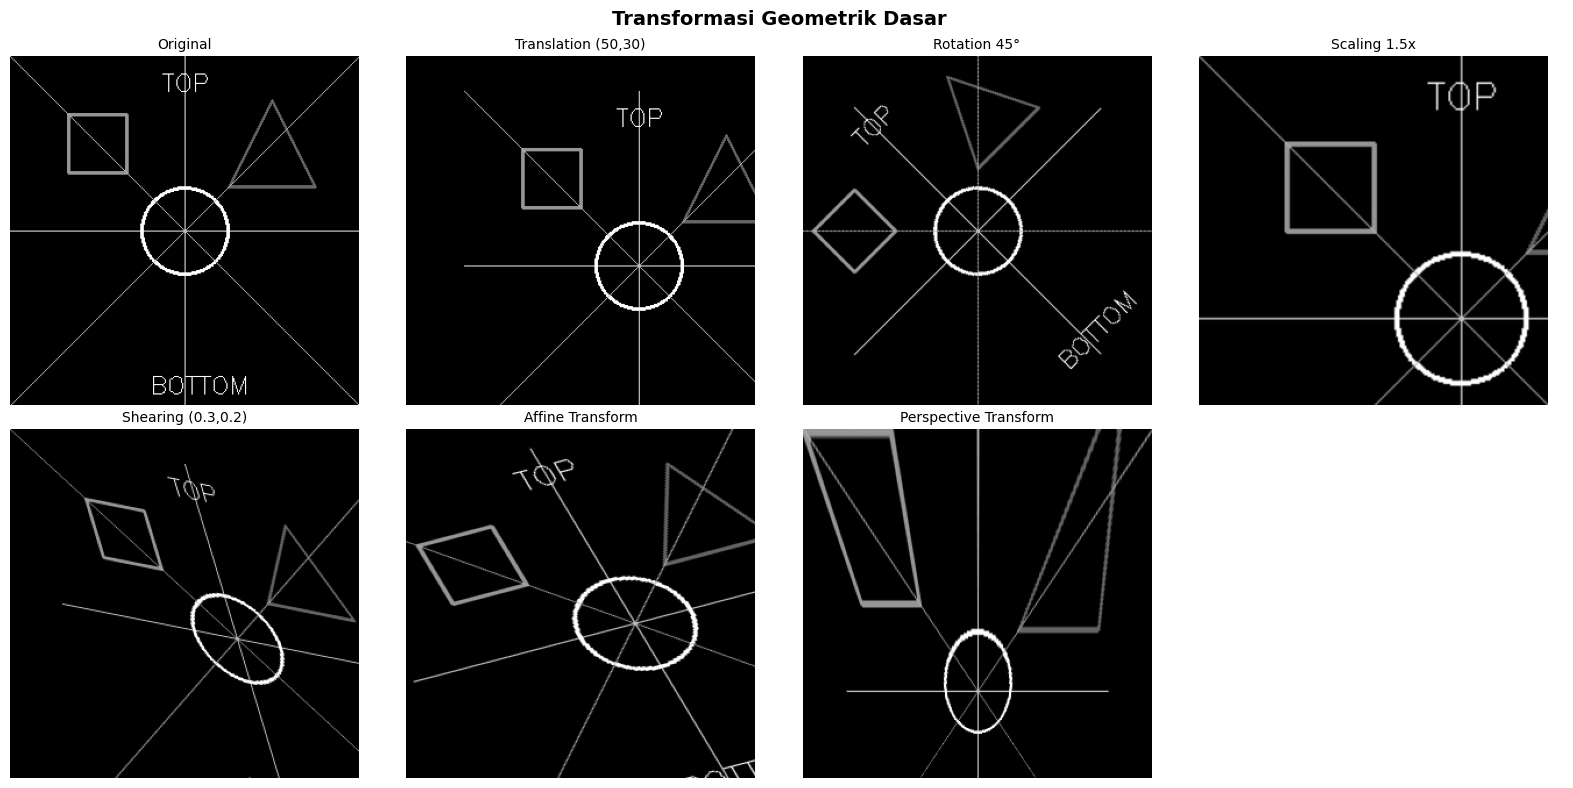


2. KOORDINAT HOMOGEN DAN MATRIKS TRANSFORMASI


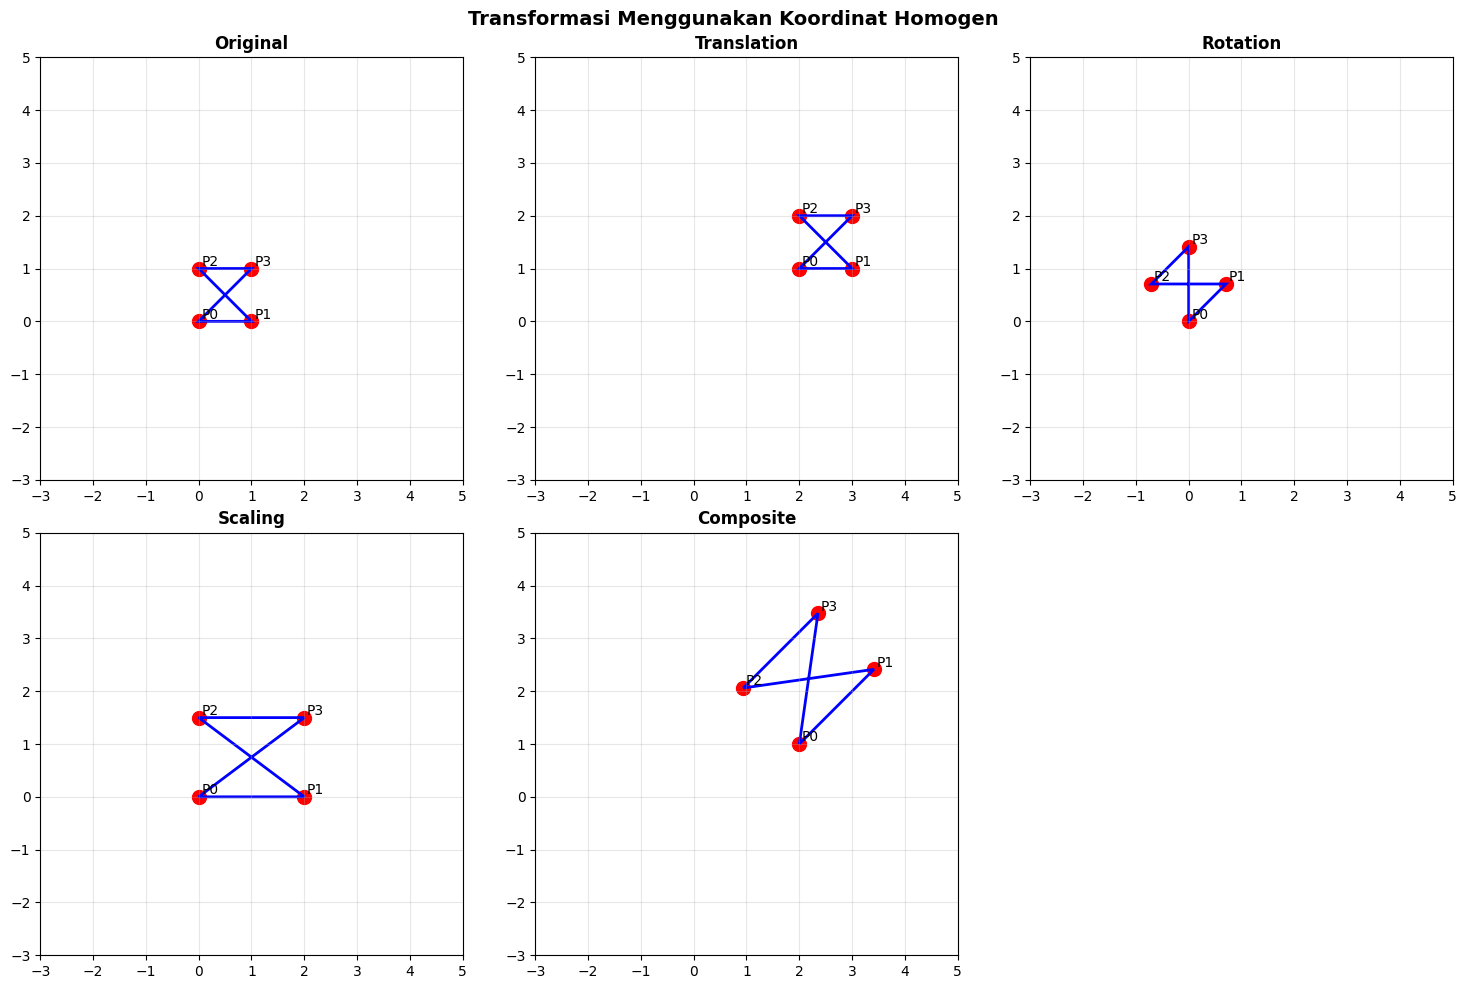


Matriks Transformasi:
Matriks Translasi (t_x=2, t_y=1):
[[1 0 2]
 [0 1 1]
 [0 0 1]]

Matriks Rotasi (θ=45°):
[[ 0.707 -0.707  0.   ]
 [ 0.707  0.707  0.   ]
 [ 0.     0.     1.   ]]

Matriks Scaling (s_x=2, s_y=1.5):
[[2.  0.  0. ]
 [0.  1.5 0. ]
 [0.  0.  1. ]]

Transformasi Komposit (Translasi → Rotasi → Scaling):
[[ 1.414 -1.061  2.   ]
 [ 1.414  1.061  1.   ]
 [ 0.     0.     1.   ]]

3. PERBANDINGAN METODE INTERPOLASI


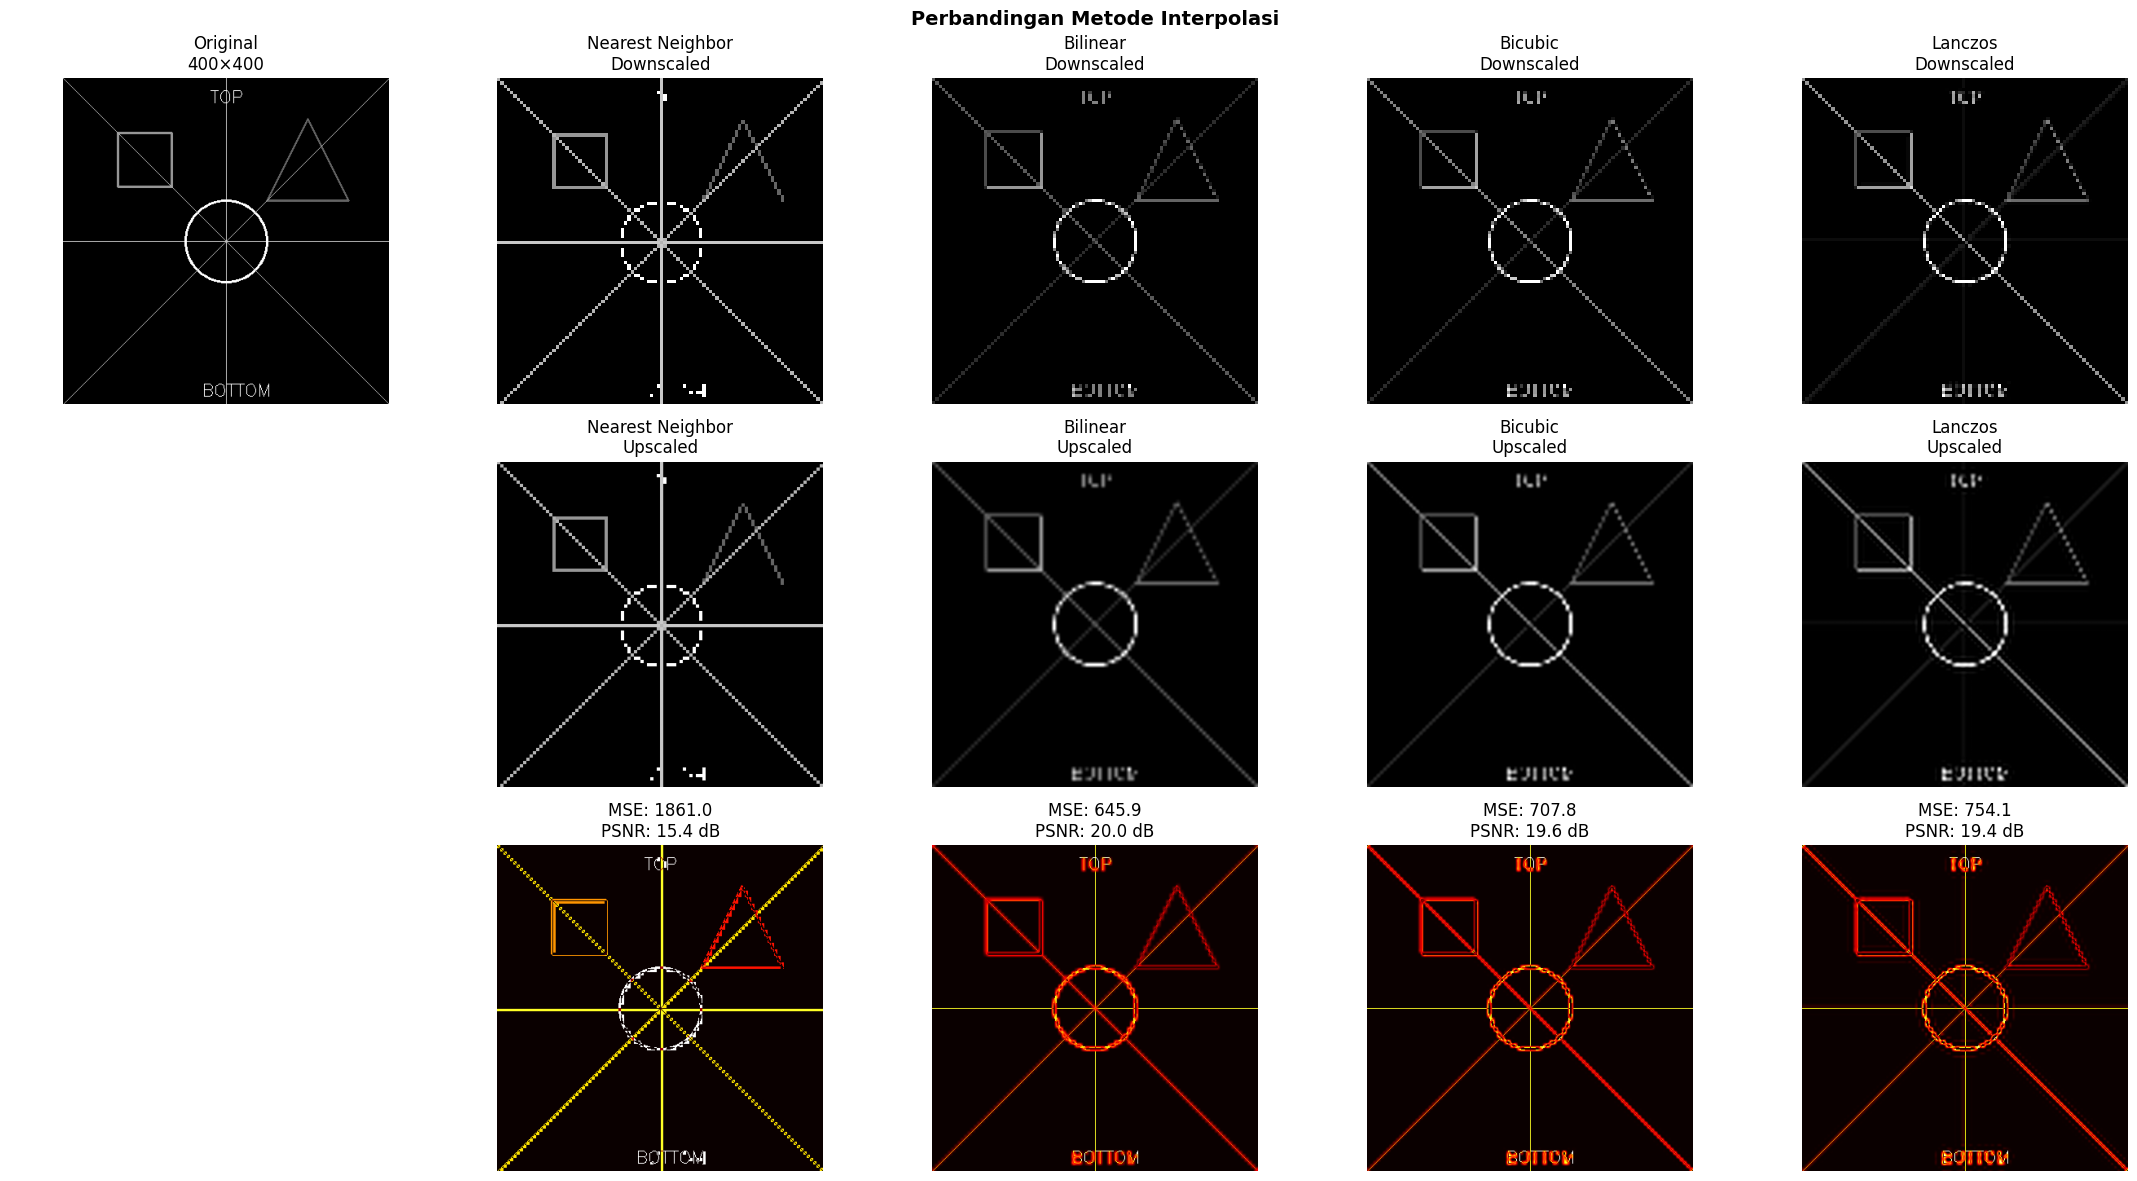


4. ANALISIS DETAIL TEKNIK INTERPOLASI


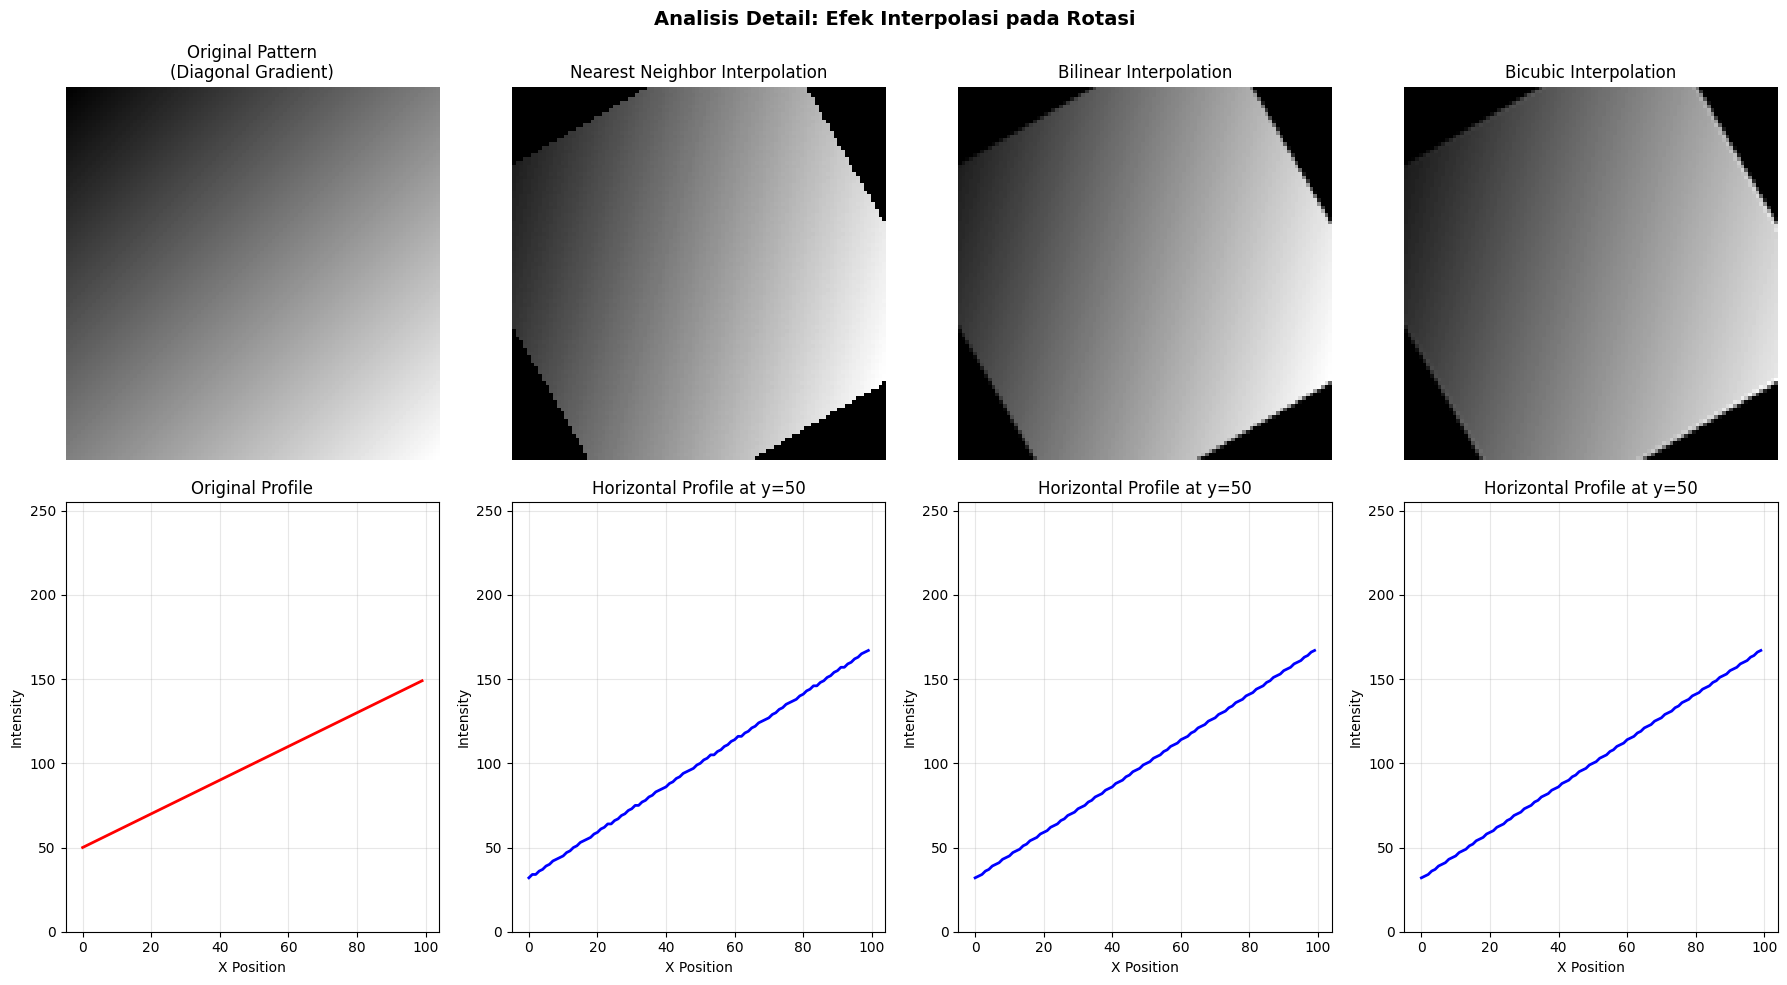


5. PERBANDINGAN DETAIL: AFFINE vs PERSPEKTIF TRANSFORM


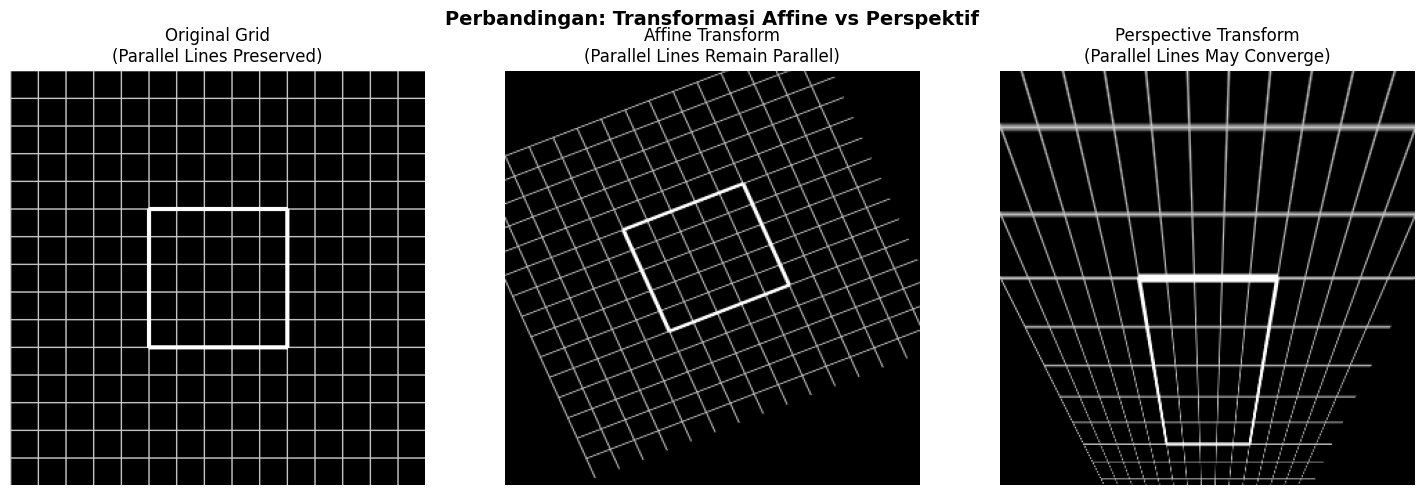


Analisis Matematis Transformasi:
Matriks Affine (3×3):
[[  0.867   0.333 -35.   ]
 [ -0.333   0.733  75.   ]]

Bentuk matriks affine:
[[a11 a12 tx]
 [a21 a22 ty]
 [0   0   1]]


Matriks Perspektif (3×3):
[[ 3.0e+00  3.0e+00 -3.0e+02]
 [ 0.0e+00  9.0e+00 -4.5e+02]
 [-0.0e+00  2.0e-02  1.0e+00]]

Bentuk matriks perspektif:
[[h11 h12 h13]
 [h21 h22 h23]
 [h31 h32 h33]]

6. APLIKASI PRAKTIS: IMAGE REGISTRATION DENGAN TRANSFORMASI GEOMETRIK
MSE sebelum registrasi : 2492.50
MSE sesudah registrasi : 371.22


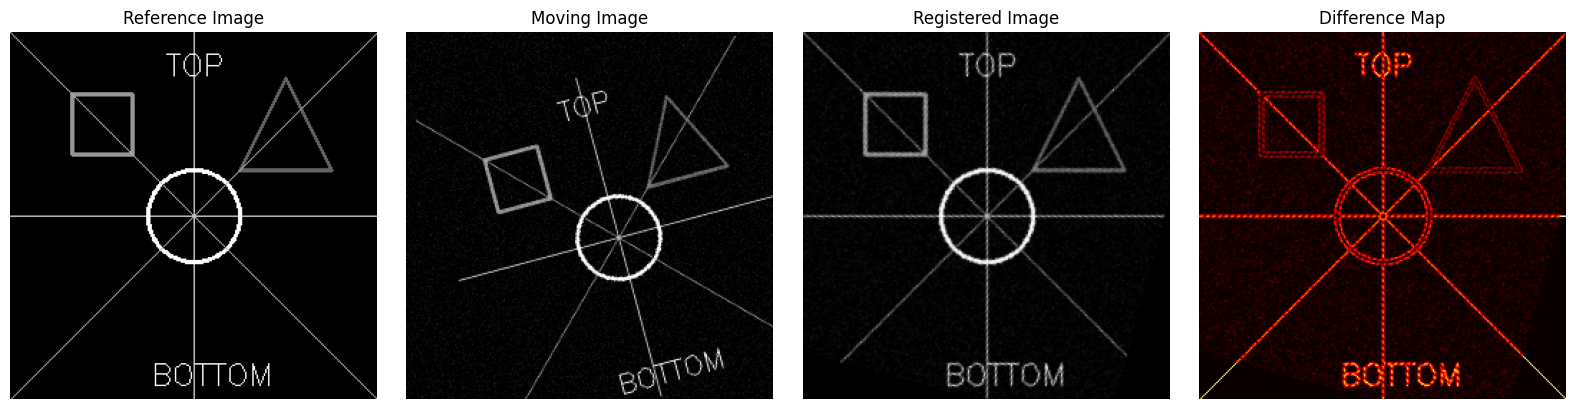

In [ ]:
# ============================================
# PRAKTIKUM 3: TRANSFORMASI GEOMETRIK DAN INTERPOLASI
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

print("=== PRAKTIKUM 3: TRANSFORMASI GEOMETRIK DAN INTERPOLASI ===")
print("Materi: Geometric Transformations, Homogeneous Coordinates, Interpolation Methods\n")

# =============== FUNGSI BANTU ===============
def create_test_image(size=256):
    """Create test image with geometric patterns"""
    img = np.zeros((size, size), dtype=np.uint8)

    # Draw coordinate axes
    cv2.line(img, (size//2, 0), (size//2, size), 200, 1)
    cv2.line(img, (0, size//2), (size, size//2), 200, 1)

    # Draw geometric shapes
    # Circle at center
    cv2.circle(img, (size//2, size//2), size//8, 255, 2)

    # Square
    square_size = size//6
    cv2.rectangle(img,
                 (size//4 - square_size//2, size//4 - square_size//2),
                 (size//4 + square_size//2, size//4 + square_size//2),
                 150, 2)

    # Triangle
    triangle_pts = np.array([
        [size*3//4, size//4 - size//8],
        [size*3//4 - size//8, size//4 + size//8],
        [size*3//4 + size//8, size//4 + size//8]
    ])
    cv2.polylines(img, [triangle_pts], True, 100, 2)

    # Diagonal lines
    cv2.line(img, (0, 0), (size, size), 180, 1)
    cv2.line(img, (size, 0), (0, size), 180, 1)

    # Add text for orientation
    cv2.putText(img, 'TOP', (size//2 - 20, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 1)
    cv2.putText(img, 'BOTTOM', (size//2 - 30, size - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 1)

    return img

def apply_transformation(image, transformation_name, params=None):
    """Apply different geometric transformations"""
    h, w = image.shape

    if transformation_name == 'translation':
        tx, ty = params.get('tx', 50), params.get('ty', 30)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        result = cv2.warpAffine(image, M, (w, h))

    elif transformation_name == 'rotation':
        angle = params.get('angle', 45)
        center = params.get('center', (w//2, h//2))
        scale = params.get('scale', 1.0)
        M = cv2.getRotationMatrix2D(center, angle, scale)
        result = cv2.warpAffine(image, M, (w, h))

    elif transformation_name == 'scaling':
        sx, sy = params.get('sx', 1.5), params.get('sy', 1.5)
        new_w, new_h = int(w * sx), int(h * sy)
        result = cv2.resize(image, (new_w, new_h))
        # Pad or crop to original size
        if sx > 1 or sy > 1:
            result = result[:h, :w]
        else:
            padded = np.zeros_like(image)
            padded[:new_h, :new_w] = result
            result = padded

    elif transformation_name == 'shearing':
        shx, shy = params.get('shx', 0.3), params.get('shy', 0.2)
        M = np.float32([[1, shx, 0], [shy, 1, 0]])
        result = cv2.warpAffine(image, M, (w, h))

    elif transformation_name == 'affine':
        # Three point affine transformation
        pts1 = np.float32([[50,50], [200,50], [50,200]])
        pts2 = np.float32([[10,100], [200,50], [100,250]])
        M = cv2.getAffineTransform(pts1, pts2)
        result = cv2.warpAffine(image, M, (w, h))

    elif transformation_name == 'perspective':
        # Four point perspective transformation
        pts1 = np.float32([[50,50], [w-50,50], [w-50,h-50], [50,h-50]])
        pts2 = np.float32([[0,0], [w,0], [w-100,h], [100,h]])
        M = cv2.getPerspectiveTransform(pts1, pts2)
        result = cv2.warpPerspective(image, M, (w, h))

    else:
        result = image.copy()

    return result

def compare_interpolation_methods(image, scale_factor=0.5):
    """Compare different interpolation methods"""
    h, w = image.shape
    new_size = (int(w * scale_factor), int(h * scale_factor))

    methods = [
        ('Nearest Neighbor', cv2.INTER_NEAREST),
        ('Bilinear', cv2.INTER_LINEAR),
        ('Bicubic', cv2.INTER_CUBIC),
        ('Lanczos', cv2.INTER_LANCZOS4)
    ]

    results = []

    for method_name, inter_flag in methods:
        # Downscale
        downscaled = cv2.resize(image, new_size, interpolation=inter_flag)
        # Upscale back to original size
        upscaled = cv2.resize(downscaled, (w, h), interpolation=inter_flag)

        # Calculate metrics
        mse = np.mean((image.astype(float) - upscaled.astype(float))**2)
        psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

        results.append({
            'name': method_name,
            'downscaled': downscaled,
            'upscaled': upscaled,
            'mse': mse,
            'psnr': psnr
        })

    return results

def visualize_homogeneous_coordinates():
    """Visualize homogeneous coordinates transformation"""
    # Create simple 2D points
    points = np.array([
        [0, 0],
        [1, 0],
        [0, 1],
        [1, 1]
    ], dtype=np.float32)

    # Transformations
    translation_matrix = np.array([
        [1, 0, 2],
        [0, 1, 1],
        [0, 0, 1]
    ])

    rotation_matrix = np.array([
        [np.cos(np.pi/4), -np.sin(np.pi/4), 0],
        [np.sin(np.pi/4), np.cos(np.pi/4), 0],
        [0, 0, 1]
    ])

    scaling_matrix = np.array([
        [2, 0, 0],
        [0, 1.5, 0],
        [0, 0, 1]
    ])

    # Convert to homogeneous coordinates
    points_homo = np.hstack([points, np.ones((len(points), 1))])

    # Apply transformations
    translated = (translation_matrix @ points_homo.T).T
    rotated = (rotation_matrix @ points_homo.T).T
    scaled = (scaling_matrix @ points_homo.T).T

    # Composite transformation
    composite = translation_matrix @ rotation_matrix @ scaling_matrix
    composite_result = (composite @ points_homo.T).T

    # Plot results
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    transformations = [
        ('Original', points_homo[:, :2]),
        ('Translation', translated[:, :2]),
        ('Rotation', rotated[:, :2]),
        ('Scaling', scaled[:, :2]),
        ('Composite', composite_result[:, :2])
    ]

    for idx, (title, pts) in enumerate(transformations):
        ax = axes[idx // 3, idx % 3]
        ax.scatter(pts[:, 0], pts[:, 1], s=100, c='red', marker='o')

        # Connect points to show shape
        polygon = plt.Polygon(pts[:4], fill=False, edgecolor='blue', linewidth=2)
        ax.add_patch(polygon)

        # Annotate points
        for i, (x, y) in enumerate(pts):
            ax.text(x + 0.05, y + 0.05, f'P{i}', fontsize=10)

        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlim(-3, 5)
        ax.set_ylim(-3, 5)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

    # Hide unused subplot
    axes[1, 2].axis('off')

    plt.suptitle('Transformasi Menggunakan Koordinat Homogen', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return points_homo, translated, rotated, scaled, composite_result

# =============== MAIN PRAKTIKUM ===============

# 1. BUAT CITRA TEST DAN DEMONSTRASI DASAR
print("\n1. TRANSFORMASI GEOMETRIK DASAR")
test_img = create_test_image(300)
h, w = test_img.shape

transformations = [
    ('Original', {'type': 'none'}),
    ('Translation (50,30)', {'type': 'translation', 'tx': 50, 'ty': 30}),
    ('Rotation 45°', {'type': 'rotation', 'angle': 45}),
    ('Scaling 1.5x', {'type': 'scaling', 'sx': 1.5, 'sy': 1.5}),
    ('Shearing (0.3,0.2)', {'type': 'shearing', 'shx': 0.3, 'shy': 0.2}),
    ('Affine Transform', {'type': 'affine'}),
    ('Perspective Transform', {'type': 'perspective'})
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, (title, params) in enumerate(transformations):
    if idx >= len(axes):
        break

    if params['type'] == 'none':
        result = test_img
    else:
        result = apply_transformation(test_img, params['type'], params)

    axes[idx].imshow(result, cmap='gray')
    axes[idx].set_title(title, fontsize=10)
    axes[idx].axis('off')

# Hide unused subplots
for i in range(len(transformations), len(axes)):
    axes[i].axis('off')

plt.suptitle('Transformasi Geometrik Dasar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. DEMONSTRASI KOORDINAT HOMOGEN
print("\n2. KOORDINAT HOMOGEN DAN MATRIKS TRANSFORMASI")
points_data = visualize_homogeneous_coordinates()

# Print transformation matrices
print("\nMatriks Transformasi:")
print("=" * 50)
print("Matriks Translasi (t_x=2, t_y=1):")
translation_matrix = np.array([[1, 0, 2], [0, 1, 1], [0, 0, 1]])
print(translation_matrix)

print("\nMatriks Rotasi (θ=45°):")
rotation_matrix = np.array([
    [np.cos(np.pi/4), -np.sin(np.pi/4), 0],
    [np.sin(np.pi/4), np.cos(np.pi/4), 0],
    [0, 0, 1]
])
print(np.round(rotation_matrix, 3))

print("\nMatriks Scaling (s_x=2, s_y=1.5):")
scaling_matrix = np.array([[2, 0, 0], [0, 1.5, 0], [0, 0, 1]])
print(scaling_matrix)

print("\nTransformasi Komposit (Translasi → Rotasi → Scaling):")
composite = translation_matrix @ rotation_matrix @ scaling_matrix
print(np.round(composite, 3))

print("\n3. PERBANDINGAN METODE INTERPOLASI")

test_img_detail = create_test_image(400)
interpolation_results = compare_interpolation_methods(test_img_detail, scale_factor=0.25)

# 3 baris x 5 kolom (1 original + 4 metode)
fig, axes = plt.subplots(3, 5, figsize=(22, 12))

# ===== BARIS 1 =====
axes[0, 0].imshow(test_img_detail, cmap='gray')
axes[0, 0].set_title('Original\n400×400')
axes[0, 0].axis('off')

for idx, result in enumerate(interpolation_results):
    axes[0, idx+1].imshow(result['downscaled'], cmap='gray')
    axes[0, idx+1].set_title(f"{result['name']}\nDownscaled")
    axes[0, idx+1].axis('off')

# ===== BARIS 2 =====
axes[1, 0].axis('off')  # kosongkan kolom pertama

for idx, result in enumerate(interpolation_results):
    axes[1, idx+1].imshow(result['upscaled'], cmap='gray')
    axes[1, idx+1].set_title(f"{result['name']}\nUpscaled")
    axes[1, idx+1].axis('off')

# ===== BARIS 3 =====
axes[2, 0].axis('off')  # kosongkan kolom pertama

for idx, result in enumerate(interpolation_results):
    error_map = np.abs(test_img_detail.astype(float) - result['upscaled'].astype(float))

    axes[2, idx+1].imshow(error_map, cmap='hot')
    axes[2, idx+1].set_title(
        f"MSE: {result['mse']:.1f}\nPSNR: {result['psnr']:.1f} dB"
    )
    axes[2, idx+1].axis('off')

plt.suptitle('Perbandingan Metode Interpolasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. ANALISIS DETAIL INTERPOLASI
print("\n4. ANALISIS DETAIL TEKNIK INTERPOLASI")

# Create high-contrast test pattern
pattern_size = 100
test_pattern = np.zeros((pattern_size, pattern_size), dtype=np.uint8)

# Create diagonal gradient
for i in range(pattern_size):
    for j in range(pattern_size):
        test_pattern[i, j] = (i + j) % 256

# Apply different interpolations with rotation
angle = 30
center = (pattern_size//2, pattern_size//2)
scale = 1.0

# Different interpolation methods
methods = [
    ('Nearest Neighbor', cv2.INTER_NEAREST),
    ('Bilinear', cv2.INTER_LINEAR),
    ('Bicubic', cv2.INTER_CUBIC)
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Original pattern
axes[0, 0].imshow(test_pattern, cmap='gray')
axes[0, 0].set_title('Original Pattern\n(Diagonal Gradient)')
axes[0, 0].axis('off')

# Rotated with different interpolations
for idx, (method_name, inter_flag) in enumerate(methods):
    M = cv2.getRotationMatrix2D(center, angle, scale)
    rotated = cv2.warpAffine(test_pattern, M, (pattern_size, pattern_size), flags=inter_flag)

    # Display rotated image
    axes[0, idx+1].imshow(rotated, cmap='gray')
    axes[0, idx+1].set_title(f'{method_name} Interpolation')
    axes[0, idx+1].axis('off')

    # Display line profile
    profile_line = rotated[pattern_size//2, :]
    axes[1, idx+1].plot(profile_line, 'b-', linewidth=2)
    axes[1, idx+1].set_title(f'Horizontal Profile at y={pattern_size//2}')
    axes[1, idx+1].set_xlabel('X Position')
    axes[1, idx+1].set_ylabel('Intensity')
    axes[1, idx+1].grid(True, alpha=0.3)
    axes[1, idx+1].set_ylim(0, 255)

# Original profile
original_profile = test_pattern[pattern_size//2, :]
axes[1, 0].plot(original_profile, 'r-', linewidth=2)
axes[1, 0].set_title('Original Profile')
axes[1, 0].set_xlabel('X Position')
axes[1, 0].set_ylabel('Intensity')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(0, 255)

plt.suptitle('Analisis Detail: Efek Interpolasi pada Rotasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. TRANSFORMASI AFFINE vs PERSPEKTIF - STUDI DETAIL
print("\n5. PERBANDINGAN DETAIL: AFFINE vs PERSPEKTIF TRANSFORM")

# Create grid image for visualization
grid_size = 300
grid_img = np.zeros((grid_size, grid_size), dtype=np.uint8)

# Draw grid
for i in range(0, grid_size, 20):
    cv2.line(grid_img, (i, 0), (i, grid_size), 200, 1)
    cv2.line(grid_img, (0, i), (grid_size, i), 200, 1)

# Draw central square
square_size = 100
cv2.rectangle(grid_img,
             (grid_size//2 - square_size//2, grid_size//2 - square_size//2),
             (grid_size//2 + square_size//2, grid_size//2 + square_size//2),
             255, 2)

# Apply transformations
# Affine: 3-point transformation
pts1_affine = np.float32([
    [grid_size//4, grid_size//4],
    [3*grid_size//4, grid_size//4],
    [grid_size//4, 3*grid_size//4]
])

pts2_affine = np.float32([
    [grid_size//4 - 20, grid_size//4 + 30],
    [3*grid_size//4 - 40, grid_size//4 - 20],
    [grid_size//4 + 30, 3*grid_size//4 - 10]
])

M_affine = cv2.getAffineTransform(pts1_affine, pts2_affine)
affine_result = cv2.warpAffine(grid_img, M_affine, (grid_size, grid_size))

# Perspective: 4-point transformation
pts1_persp = np.float32([
    [50, 50],
    [grid_size-50, 50],
    [grid_size-50, grid_size-50],
    [50, grid_size-50]
])

pts2_persp = np.float32([
    [0, 0],
    [grid_size, 0],
    [grid_size-100, grid_size],
    [100, grid_size]
])

M_persp = cv2.getPerspectiveTransform(pts1_persp, pts2_persp)
persp_result = cv2.warpPerspective(grid_img, M_persp, (grid_size, grid_size))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original grid
axes[0].imshow(grid_img, cmap='gray')
axes[0].set_title('Original Grid\n(Parallel Lines Preserved)')
axes[0].axis('off')

# Affine transform
axes[1].imshow(affine_result, cmap='gray')
axes[1].set_title('Affine Transform\n(Parallel Lines Remain Parallel)')
axes[1].axis('off')

# Perspective transform
axes[2].imshow(persp_result, cmap='gray')
axes[2].set_title('Perspective Transform\n(Parallel Lines May Converge)')
axes[2].axis('off')

plt.suptitle('Perbandingan: Transformasi Affine vs Perspektif', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mathematical comparison
print("\nAnalisis Matematis Transformasi:")
print("=" * 50)
print("Matriks Affine (3×3):")
print(np.round(M_affine, 3))
print(f"\nBentuk matriks affine:\n[[a11 a12 tx]\n [a21 a22 ty]\n [0   0   1]]")

print("\n\nMatriks Perspektif (3×3):")
print(np.round(M_persp, 3))
print(f"\nBentuk matriks perspektif:\n[[h11 h12 h13]\n [h21 h22 h23]\n [h31 h32 h33]]")

# 6. APLIKASI PRAKTIS: IMAGE REGISTRATION
print("\n6. APLIKASI PRAKTIS: IMAGE REGISTRATION DENGAN TRANSFORMASI GEOMETRIK")

def demonstrate_image_registration():
    """Demonstrate image registration using geometric transformations"""

    # Create reference image
    ref_img = create_test_image(256)

    # Create moving image (rotasi + scaling + translasi)
    M_combined = cv2.getRotationMatrix2D((128, 128), 15, 0.9)
    M_combined[0, 2] += 20
    M_combined[1, 2] += 15

    moving_img = cv2.warpAffine(ref_img, M_combined, (256, 256))

    # Tambahkan noise
    noise = np.random.normal(0, 10, moving_img.shape)
    moving_img = np.clip(moving_img.astype(float) + noise, 0, 255).astype(np.uint8)

    # ===============================
    # REGISTRATION (Inverse Transform)
    # ===============================

    # Ubah matrix 2x3 jadi 3x3 (homogeneous)
    M_full = np.vstack([M_combined, [0, 0, 1]])

    # Hitung inverse matrix
    M_inverse = np.linalg.inv(M_full)

    # Ambil kembali 2x3 untuk warpAffine
    M_inverse_affine = M_inverse[:2, :]

    # Apply inverse transformation
    registered_img = cv2.warpAffine(moving_img, M_inverse_affine, (256, 256))

    # ===============================
    # Hitung Error
    # ===============================

    mse_before = np.mean((ref_img.astype(float) - moving_img.astype(float))**2)
    mse_after = np.mean((ref_img.astype(float) - registered_img.astype(float))**2)

    print(f"MSE sebelum registrasi : {mse_before:.2f}")
    print(f"MSE sesudah registrasi : {mse_after:.2f}")

    # ===============================
    # Visualisasi
    # ===============================

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(ref_img, cmap='gray')
    axes[0].set_title("Reference Image")
    axes[0].axis('off')

    axes[1].imshow(moving_img, cmap='gray')
    axes[1].set_title("Moving Image")
    axes[1].axis('off')

    axes[2].imshow(registered_img, cmap='gray')
    axes[2].set_title("Registered Image")
    axes[2].axis('off')

    diff_map = np.abs(ref_img.astype(float) - registered_img.astype(float))
    axes[3].imshow(diff_map, cmap='hot')
    axes[3].set_title("Difference Map")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    return ref_img, moving_img, registered_img


# Jalankan
ref_img, moving_img, registered_img = demonstrate_image_registration()